In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# S00 — Begin with one observation, not a model

Read the matching lesson before running. Predictions first; source facts, manufactured controls and interpretations are labeled separately. This is not a sports performance benchmark.

In [2]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
from dataclasses import asdict
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/shape_lab').exists())
sys.path.insert(0, str(ROOT / 'src'))
from shape_lab import sports_v8 as sport
from shape_lab.persistence import finite_bottleneck
spl, profiles = sport.load_sports(ROOT)
frames = np.array([r['frame'] for r in spl['records']])
times = sport.frame_times(frames, spl['sampling_rate'])
ball = sport.to_metres([r['ball'] for r in spl['records']], spl['xyz_unit'])
report_dir = ROOT / 'reports/v8/sports'
report_dir.mkdir(parents=True, exist_ok=True)
def save_report(stage, result):
    # Reports contain ordinary finite values; absent values are recorded explicitly.
    (report_dir / f'{stage}.json').write_text(json.dumps(result, indent=2, allow_nan=False) + '\n')
print('Data:', len(frames), 'selected frames from one shot;', len(profiles), 'profiles from', profiles.player_id.nunique(), 'players')


Data: 12 selected frames from one shot; 12 profiles from 8 players


## Inspect before interpreting

In [3]:
print(json.dumps({k:v for k,v in spl.items() if k != 'records'}, indent=2))
display(profiles.head(6))
assert profiles.player_id.nunique() == 8
assert len({spl['participant_id']}) == 1


{
  "dataset": "SPL Open Data",
  "session": "2025-12-18",
  "participant_id": "P0001",
  "trial_id": "T0001",
  "sampling_rate": 60,
  "xyz_unit": "ft",
  "frame_time_policy": "frame / sampling_rate (ideal sample clock; not synchronized camera PTS)",
  "result": "made",
  "landing_x": -2.54,
  "landing_y": 10.45,
  "landing_unit": "in",
  "entry_angle_deg": 45.4
}


,source_row,player_id,team_id,season_id,position_group,minutes_full_all,count_match,total_distance_full_all,total_metersperminute_full_all,running_distance_full_all,hsr_distance_full_all,sprint_distance_full_all
0,1,211,871,95,Center Forward,96.78,24,10515.04,108.64,1413.42,572.67,184.08
1,2,218,868,95,Full Back,89.05,6,9173.67,103.02,1088.83,430.67,141.33
2,3,2759,1804,95,Central Defender,96.46,8,9563.50,99.14,1041.12,281.25,38.25
3,4,2858,869,95,Center Forward,94.25,4,10521.25,111.64,1425.50,406.75,71.25
4,5,2858,869,95,Midfield,67.57,1,7843.00,116.08,1307.00,318.00,10.00
5,6,2858,869,95,Wide Attacker,94.89,4,10349.25,109.07,1593.75,551.75,95.75


## One quantity, two unit representations

In [4]:
first_ft = np.array(spl['records'][0]['ball'])
first_m = sport.to_metres(first_ft, 'ft')
assert np.allclose(first_m / .3048, first_ft)
print('First ball xyz in feet:', first_ft)
print('Same point in metres:', first_m)
print('Hoop offset is a different frame:', sport.to_metres([spl['landing_x'], spl['landing_y']], 'in'))


First ball xyz in feet: [ 18.80024277 -25.52941356   3.20205094]
Same point in metres: [ 5.730314   -7.78136525  0.97598513]
Hoop offset is a different frame: [-0.064516  0.26543 ]


## Source grain and repeated identity

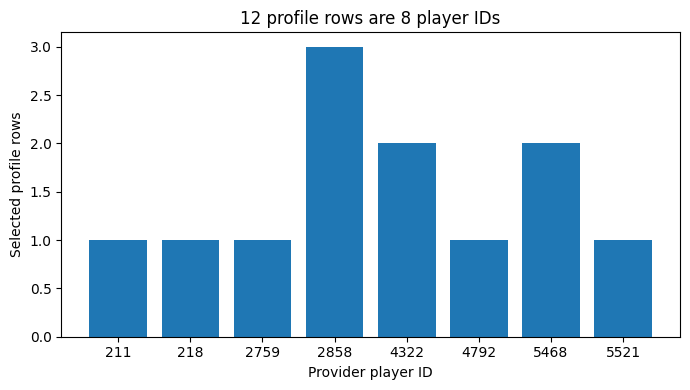

In [5]:
counts = profiles.groupby('player_id').size()
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(counts.index.astype(str), counts.values)
ax.set(xlabel='Provider player ID', ylabel='Selected profile rows', title='12 profile rows are 8 player IDs')
fig.tight_layout(); plt.show()
save_report('S00', {'selected_frames':len(frames),'selected_shots':1,'profile_rows':len(profiles),'distinct_player_ids':int(profiles.player_id.nunique()),'local_integrity':sport.verify_local_data(ROOT),'remote_source_equality_verified':False})


## Independent explanation
State the observation unit, assumptions, units, one result and one unsupported conclusion. Then work the separate learner notebook without the answer notebook open.